# Optimizacion Bayesiana

**Teorema de Bayes**

$$ P(A|B) = \frac{P(B|A) P(A)}{P(B)} $$

- $ P(A|B) $: Probabilidad posterior de A dado B
- $ P(B|A) $: Verosimilitud (likelihood)
- $ P(A) $: Probabilidad a priori
- $ P(B) $: Evidencia

$$ \text{posterior} = \frac{(\text{verosimilitud})(\text{anterior})}{\text{evidencia}} $$

## Ejemplo: Proceso Gaussiano para Optimizacion Bayesiana

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
import warnings
warnings.filterwarnings('ignore')

### Paso 1: Comenzamos con pocos puntos conocidos

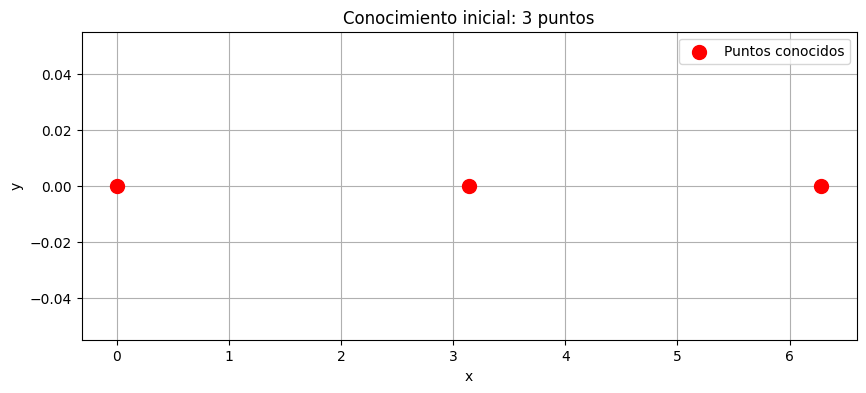

In [2]:
# Puntos iniciales conocidos
X_conocidos = np.array([[0], [np.pi], [2*np.pi]])
y_conocidos = np.array([0, 0, 0])

plt.figure(figsize=(10, 4))
plt.scatter(X_conocidos, y_conocidos, s=100, c='red', zorder=5, label='Puntos conocidos')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Conocimiento inicial: 3 puntos')
plt.grid(True)
plt.legend()
plt.show()

### Paso 2: Regresion con Proceso Gaussiano

Usamos un Proceso Gaussiano para modelar la incertidumbre sobre la funcion desconocida.

In [3]:
# Definir el kernel
kernel = C(1.0) * RBF(length_scale=1.0)

# Crear el modelo de Proceso Gaussiano
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)

# Ajustar con los puntos conocidos
gp.fit(X_conocidos, y_conocidos)

print("Modelo ajustado con", len(X_conocidos), "puntos")

Modelo ajustado con 3 puntos


### Paso 3: Predecir y graficar con intervalos de confianza

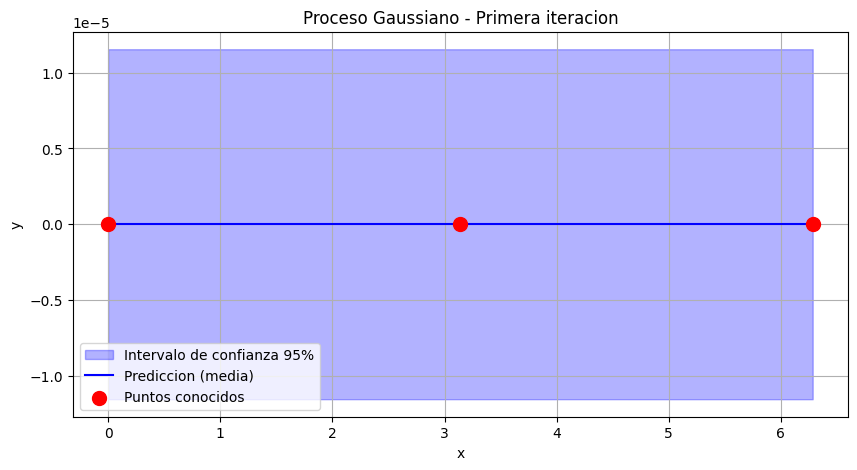

In [4]:
# Crear vector de valores posibles de x
X_pred = np.linspace(0, 2*np.pi, 100).reshape(-1, 1)

# Predecir con el GP (media y desviacion estandar)
y_pred, y_std = gp.predict(X_pred, return_std=True)

# Graficar
plt.figure(figsize=(10, 5))

# Intervalo de confianza (2 desviaciones estandar = 95%)
plt.fill_between(X_pred.ravel(), 
                 y_pred - 2*y_std, 
                 y_pred + 2*y_std, 
                 alpha=0.3, color='blue', label='Intervalo de confianza 95%')

# Prediccion media
plt.plot(X_pred, y_pred, 'b-', label='Prediccion (media)')

# Puntos conocidos
plt.scatter(X_conocidos, y_conocidos, s=100, c='red', zorder=5, label='Puntos conocidos')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Proceso Gaussiano - Primera iteracion')
plt.legend()
plt.grid(True)
plt.show()

### Criterios de seleccion del siguiente punto

Hay varias formas de elegir donde muestrear:
- **Maximizar**: buscar el maximo predicho
- **Minimizar**: buscar el minimo predicho
- **Reducir incertidumbre**: buscar donde el intervalo de confianza es mas grande

In [5]:
# Criterio: Reducir incertidumbre (buscar max desviacion estandar)
idx_max_incertidumbre = np.argmax(y_std)
x_nuevo = X_pred[idx_max_incertidumbre][0]

print(f"Siguiente punto a muestrear (max incertidumbre): x = {x_nuevo:.4f}")
print(f"Desviacion estandar en ese punto: {y_std[idx_max_incertidumbre]:.4f}")

Siguiente punto a muestrear (max incertidumbre): x = 0.0000
Desviacion estandar en ese punto: 0.0000


### Paso 4: Agregar nuevo punto y repetir

In [6]:
# Funcion real (simulada) - en la practica no la conocemos
def funcion_real(x):
    return np.sin(x)

# Obtener el valor real del nuevo punto
y_nuevo = funcion_real(x_nuevo)

# Agregar a nuestros datos conocidos
X_conocidos = np.vstack([X_conocidos, [[x_nuevo]]])
y_conocidos = np.append(y_conocidos, y_nuevo)

print(f"Nuevo punto agregado: ({x_nuevo:.4f}, {y_nuevo:.4f})")
print(f"Total de puntos conocidos: {len(X_conocidos)}")

Nuevo punto agregado: (0.0000, 0.0000)
Total de puntos conocidos: 4


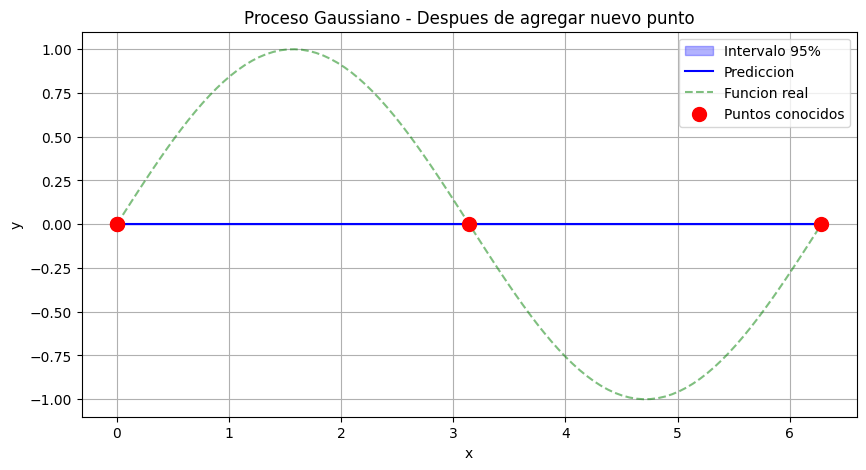

In [7]:
# Reajustar el modelo con el nuevo punto
gp.fit(X_conocidos, y_conocidos)

# Predecir de nuevo
y_pred, y_std = gp.predict(X_pred, return_std=True)

# Graficar
plt.figure(figsize=(10, 5))
plt.fill_between(X_pred.ravel(), y_pred - 2*y_std, y_pred + 2*y_std, 
                 alpha=0.3, color='blue', label='Intervalo 95%')
plt.plot(X_pred, y_pred, 'b-', label='Prediccion')
plt.plot(X_pred, funcion_real(X_pred), 'g--', label='Funcion real', alpha=0.5)
plt.scatter(X_conocidos, y_conocidos, s=100, c='red', zorder=5, label='Puntos conocidos')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Proceso Gaussiano - Despues de agregar nuevo punto')
plt.legend()
plt.grid(True)
plt.show()

### Repetir el proceso 30 veces con una funcion distinta

$$ f(x) = \sin{(\frac{x}{3})} + \cos{(2x)}, \ \ \ \ x \in [-5\pi, 5\pi] $$

In [8]:
# Nueva funcion objetivo
def f_objetivo(x):
    return np.sin(x/3) + np.cos(2*x)

# Dominio
x_min, x_max = -5*np.pi, 5*np.pi

# Puntos iniciales (3 puntos aleatorios)
np.random.seed(42)
X_obs = np.random.uniform(x_min, x_max, 3).reshape(-1, 1)
y_obs = f_objetivo(X_obs.ravel())

# Vector para predicciones
X_plot = np.linspace(x_min, x_max, 500).reshape(-1, 1)

print(f"Puntos iniciales: {X_obs.ravel()}")

Puntos iniciales: [-3.94143841 14.15960754  7.28830463]


In [9]:
# Optimizacion Bayesiana: 30 iteraciones
n_iteraciones = 30

# Kernel
kernel = C(1.0) * RBF(length_scale=1.0)

for i in range(n_iteraciones):
    # 1. Ajustar GP
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, random_state=i)
    gp.fit(X_obs, y_obs)
    
    # 2. Predecir
    y_pred, y_std = gp.predict(X_plot, return_std=True)
    
    # 3. Seleccionar siguiente punto (criterio: max incertidumbre)
    idx_next = np.argmax(y_std)
    x_next = X_plot[idx_next][0]
    y_next = f_objetivo(x_next)
    
    # 4. Agregar nuevo punto
    X_obs = np.vstack([X_obs, [[x_next]]])
    y_obs = np.append(y_obs, y_next)
    
    # Mostrar progreso cada 10 iteraciones
    if (i+1) % 10 == 0:
        print(f"Iteracion {i+1}: {len(X_obs)} puntos")

print(f"\nTotal de puntos: {len(X_obs)}")

Iteracion 10: 13 puntos
Iteracion 20: 23 puntos
Iteracion 30: 33 puntos

Total de puntos: 33


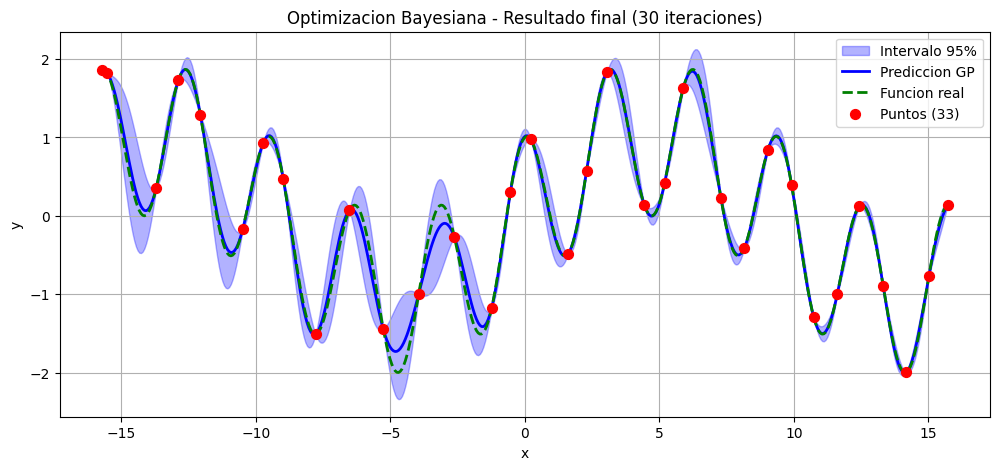

In [10]:
# Grafica final
gp.fit(X_obs, y_obs)
y_pred, y_std = gp.predict(X_plot, return_std=True)

plt.figure(figsize=(12, 5))
plt.fill_between(X_plot.ravel(), y_pred - 2*y_std, y_pred + 2*y_std, 
                 alpha=0.3, color='blue', label='Intervalo 95%')
plt.plot(X_plot, y_pred, 'b-', lw=2, label='Prediccion GP')
plt.plot(X_plot, f_objetivo(X_plot), 'g--', lw=2, label='Funcion real')
plt.scatter(X_obs, y_obs, s=50, c='red', zorder=5, label=f'Puntos ({len(X_obs)})')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Optimizacion Bayesiana - Resultado final (30 iteraciones)')
plt.legend()
plt.grid(True)
plt.show()

## Actividad

1. Modificar el comportamiento de seleccion para elegir el **maximo** de las predicciones como el siguiente punto.
2. Modificar el comportamiento de seleccion para elegir el **minimo** de las predicciones como el siguiente punto.

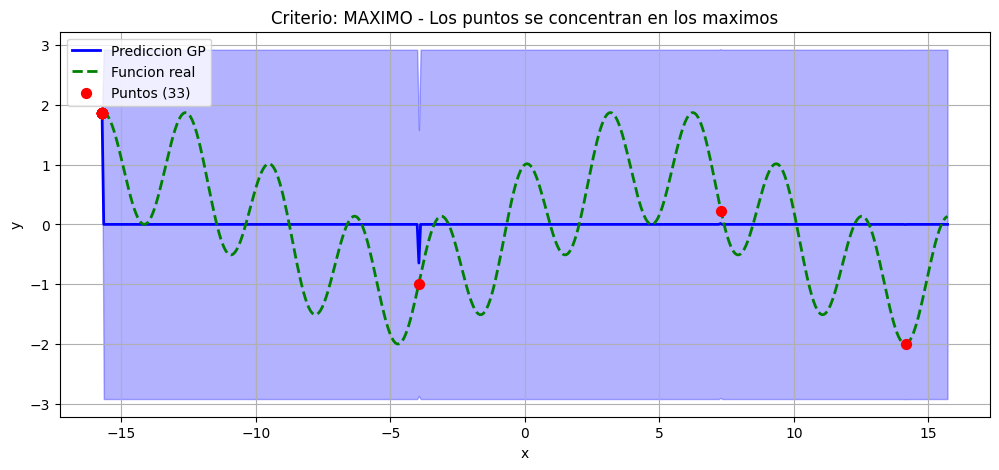

Maximo encontrado: y = 1.8660 en x = -15.7080
Maximo real: y = 1.8694


In [11]:
# Reiniciar
np.random.seed(42)
X_obs_max = np.random.uniform(x_min, x_max, 3).reshape(-1, 1)
y_obs_max = f_objetivo(X_obs_max.ravel())

for i in range(n_iteraciones):
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, random_state=i)
    gp.fit(X_obs_max, y_obs_max)
    
    y_pred, y_std = gp.predict(X_plot, return_std=True)
    
    # CAMBIO: Seleccionar el MAXIMO de la prediccion
    idx_next = np.argmax(y_pred)
    x_next = X_plot[idx_next][0]
    y_next = f_objetivo(x_next)
    
    X_obs_max = np.vstack([X_obs_max, [[x_next]]])
    y_obs_max = np.append(y_obs_max, y_next)

# Graficar resultado
gp.fit(X_obs_max, y_obs_max)
y_pred, y_std = gp.predict(X_plot, return_std=True)

plt.figure(figsize=(12, 5))
plt.fill_between(X_plot.ravel(), y_pred - 2*y_std, y_pred + 2*y_std, alpha=0.3, color='blue')
plt.plot(X_plot, y_pred, 'b-', lw=2, label='Prediccion GP')
plt.plot(X_plot, f_objetivo(X_plot), 'g--', lw=2, label='Funcion real')
plt.scatter(X_obs_max, y_obs_max, s=50, c='red', zorder=5, label=f'Puntos ({len(X_obs_max)})')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Criterio: MAXIMO - Los puntos se concentran en los maximos')
plt.legend()
plt.grid(True)
plt.show()

print(f"Maximo encontrado: y = {np.max(y_obs_max):.4f} en x = {X_obs_max[np.argmax(y_obs_max)][0]:.4f}")
print(f"Maximo real: y = {np.max(f_objetivo(X_plot)):.4f}")

ACTIVIDAD 2: Criterio de seleccion = MINIMO


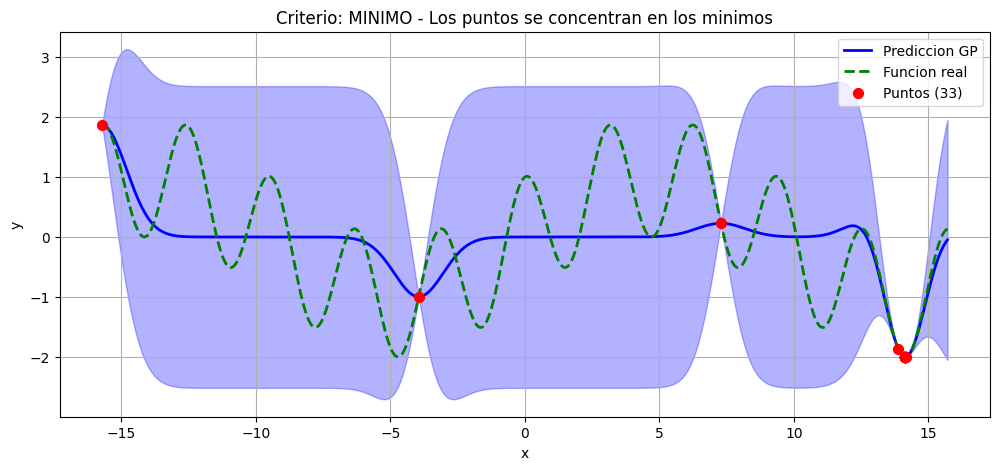

Minimo encontrado: y = -2.0000 en x = 14.1340
Minimo real: y = -2.0000


In [12]:
# ACTIVIDAD 2: Seleccionar el MINIMO de las predicciones
print("=" * 60)
print("ACTIVIDAD 2: Criterio de seleccion = MINIMO")
print("=" * 60)

# Reiniciar
np.random.seed(42)
X_obs_min = np.random.uniform(x_min, x_max, 3).reshape(-1, 1)
y_obs_min = f_objetivo(X_obs_min.ravel())

for i in range(n_iteraciones):
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, random_state=i)
    gp.fit(X_obs_min, y_obs_min)
    
    y_pred, y_std = gp.predict(X_plot, return_std=True)
    
    # CAMBIO: Seleccionar el MINIMO de la prediccion
    idx_next = np.argmin(y_pred)
    x_next = X_plot[idx_next][0]
    y_next = f_objetivo(x_next)
    
    X_obs_min = np.vstack([X_obs_min, [[x_next]]])
    y_obs_min = np.append(y_obs_min, y_next)

# Graficar resultado
gp.fit(X_obs_min, y_obs_min)
y_pred, y_std = gp.predict(X_plot, return_std=True)

plt.figure(figsize=(12, 5))
plt.fill_between(X_plot.ravel(), y_pred - 2*y_std, y_pred + 2*y_std, alpha=0.3, color='blue')
plt.plot(X_plot, y_pred, 'b-', lw=2, label='Prediccion GP')
plt.plot(X_plot, f_objetivo(X_plot), 'g--', lw=2, label='Funcion real')
plt.scatter(X_obs_min, y_obs_min, s=50, c='red', zorder=5, label=f'Puntos ({len(X_obs_min)})')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Criterio: MINIMO - Los puntos se concentran en los minimos')
plt.legend()
plt.grid(True)
plt.show()

print(f"Minimo encontrado: y = {np.min(y_obs_min):.4f} en x = {X_obs_min[np.argmin(y_obs_min)][0]:.4f}")
print(f"Minimo real: y = {np.min(f_objetivo(X_plot)):.4f}")

## Comparacion de los 3 criterios

In [13]:
print("=" * 60)
print("RESUMEN: Comparacion de criterios de seleccion")
print("=" * 60)
print(f"{'Criterio':<25} {'Uso':<35}")
print("-" * 60)
print(f"{'Max Incertidumbre':<25} {'Explorar toda la funcion':<35}")
print(f"{'Maximo predicho':<25} {'Encontrar el maximo global':<35}")
print(f"{'Minimo predicho':<25} {'Encontrar el minimo global':<35}")

RESUMEN: Comparacion de criterios de seleccion
Criterio                  Uso                                
------------------------------------------------------------
Max Incertidumbre         Explorar toda la funcion           
Maximo predicho           Encontrar el maximo global         
Minimo predicho           Encontrar el minimo global         
